<div style="display: flex; align-items: center; gap: 20px; font-family: Arial, sans-serif;">
    <div style="margin-right: 30px;">
        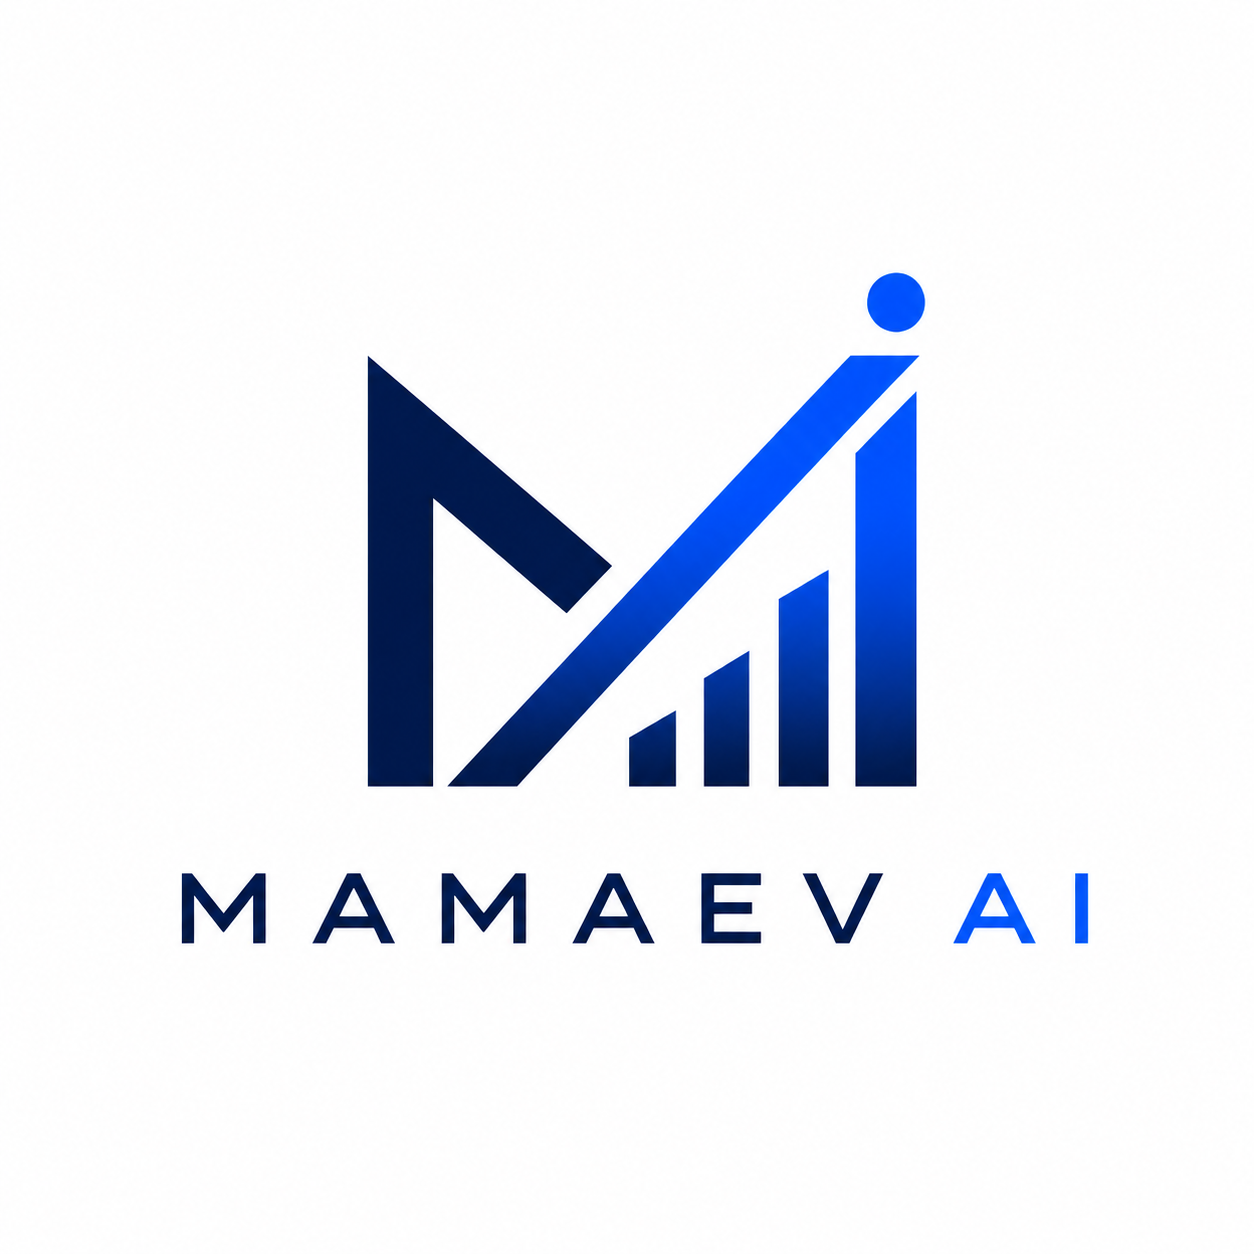
    </div>
    <div style="line-height: 1.5;">
        <strong style="font-size: 18px; display: block; margin-bottom: 5px;">
            <a href='https://t.me/M4m4ev_Alex' style="text-decoration: none; color: #1a73e8;">
                Репетитор по информатике | Мамаев Алексей
            </a>
        </strong>
        <span style="font-size: 16px; color: #333;">
            Разбор <a href='https://coderun.yandex.ru/problem/cheapest-way' style="text-decoration: none; color: #1a73e8;">
            2-й задачи</a> CodeRun
        </span>
        <span style="font-size: 16px; color: #333;">
            <br><br><br><br><br><br>ТГК: <a href='https://t.me/M4m4ev_Alex' style="text-decoration: none; color: #1a73e8;">@M4m4ev_Alex</a><br>
        </span>
    </div>
</div>

## Задача 2. Самый дешевый путь  

---

### Условие

В каждой клетке прямоугольной таблицы **N×M** записано некоторое число. Изначально игрок находится в левой верхней клетке. За один ход ему разрешается перемещаться в соседнюю клетку либо **вправо**, либо **вниз** (**влево** и **вверх** перемещаться запрещено). При проходе через клетку с игрока берут столько килограммов еды, какое число записано в этой клетке (**еду берут также за первую и последнюю клетки его пути**).

---

### Требуется

Найти **минимальный вес еды в килограммах**, отдав которую игрок может попасть в правый нижний угол.

---

### Формат ввода

Вводятся два числа **N** и **M** — размеры таблицы (1 ≤ N ≤ 20, 1 ≤ M ≤ 20).  
Затем идёт **N строк по M чисел** в каждой — размеры штрафов в килограммах за прохождение через соответствующие клетки (числа от 0 до 100).

---

### Формат вывода

Выведите минимальный вес еды в килограммах, отдав которую можно попасть в правый нижний угол.

---

### Ограничения

- Время: 1 с  
- Память: 256 МБ

---

### Пример

**Ввод**
```text
5 5
1 1 1 1 1
3 100 100 100 100
1 1 1 1 1
2 2 2 2 1
1 1 1 1 1
```

**Вывод**
```text
11
```

## Разбор решения

Это классическое решение задачи на динамическое программирование для поиска минимального пути в таблице. Идея в том, что в каждую клетку можно попасть только **сверху** или **слева**, поэтому минимальный путь до клетки `(i, j)` равен минимальному из путей до соседних клеток плюс стоимость текущей клетки.  

Сначала обрабатываются **первая строка** и **первый столбец**, так как в них путь может идти только одним направлением (вправо или вниз). Далее для всех остальных клеток выбирается минимальный путь из двух возможных вариантов. В итоге, после заполнения всей таблицы, минимальный путь до правого нижнего угла находится в соответствующей клетке.  

Алгоритм работает за **O(n × m)** по времени и использует исходную матрицу для хранения промежуточных результатов, поэтому дополнительная память не требуется.

In [1]:
def get_result_1() -> int: 
    n, m = map(int, input().split())
    matrix = [list(map(int, input().split())) for _ in range(n)]
    
    for i in range(1, m):
        matrix[0][i] += matrix[0][i - 1]
        
    for i in range(1, n):
        matrix[i][0] += matrix[i - 1][0]

    for i in range(1, n):
        for j in range(1, m):
            matrix[i][j] += min(matrix[i - 1][j], matrix[i][j - 1]) 
    
    return matrix[n - 1][m - 1]


print(get_result_1())

 5 5
 1 1 1 1 1
 3 100 100 100 100
 1 1 1 1 1
 2 2 2 2 1
 1 1 1 1 1


11


## Разбор решения (вариант с двумя строками)

Этот вариант также использует **динамическое программирование**, но **оптимизирован по памяти**.  

Идея такая же: минимальный путь до каждой клетки `(i, j)` равен минимальному пути до соседних клеток (слева и сверху) плюс стоимость текущей клетки.  

### Отличия от первого варианта:

1. **Хранение только двух строк:**  
   - Вместо полной матрицы хранятся только текущая строка `line_2` и предыдущая `line_1`.  
   - Это экономит память, особенно для больших таблиц.

2. **Пошаговое заполнение:**  
   - Для первой строки накапливается сумма слева.  
   - Для остальных строк первый элемент накапливается сверху, остальные элементы — минимум между значением слева и значением сверху.

### Итог

В конце в последней строке хранится минимальный путь до каждой клетки последней строки, и ответ находится в правом нижнем углу.  

Сложность алгоритма:

- **Время:** O(n × m) — как и в первом варианте  
- **Память:** O(m) — вместо O(n × m) в первом решении

In [2]:
def get_result_2() -> int:
    n, m = map(int, input().split())

    line_1 = []
    for i in range(n):
        line_2 = list(map(int, input().split()))
        if not line_1:
            for j in range(1, m):
                line_2[j] += line_2[j - 1]
        else:
            line_2[0] += line_1[0]
            for j in range(1, m):
                line_2[j] += min(line_2[j - 1], line_1[j])
        line_1 = line_2
        
    return line_1[m - 1]


print(get_result_2())

 5 5
 1 1 1 1 1
 3 100 100 100 100
 1 1 1 1 1
 2 2 2 2 1
 1 1 1 1 1


11


## Вывод

Оба решения используют **динамическое программирование** для нахождения минимального пути в таблице.  

- Первый вариант хранит **всю матрицу**, что проще для понимания и наглядно показывает промежуточные результаты.  
- Второй вариант **оптимизирован по памяти**, хранит только две строки, что снижает потребление памяти до O(m).  

По времени оба решения эквивалентны: **O(n × m)**, и дают одинаковый правильный результат